#Reading From Spectrum Analyzer

The SpectrumAnalyzer uses kiss_fft to produce bins based off the fftSize_. We drop the nyquist bin, and each value is normalized magnitude in db. Phase is discarded. The analyzer overlaps windows 50% to keep a smooth transition from frame to frame -- meaning consecutive packets are not independent time slices.

default fft_size = 4096 (config.json "analysis.spectrum_analyzer.buffer_size")
default sample_rate = 48000, but will change based on the peripheral audio output defined

To start, we just need to load in the data and then re-align the bins with frequencies based on our established sample rate and fft size.

In [6]:
import numpy as np

# load component from .npy file
def load_component(npy_path):
    arr = np.load(npy_path)
    timestamps = arr[:, 0]
    bins = arr[:, 1:]
    # strip NaN padding columns if packet sizes varied
    valid_cols = ~np.all(np.isnan(bins), axis=0)
    bins = bins[:, valid_cols]
    return timestamps, bins

# line up the frequency to bins based on fft size / sample rate
def bin_freqs(n_bins, fft_size, sample_rate):
    inferred_fft_size = fft_size or n_bins * 2 
    return np.arange(n_bins) * sample_rate / inferred_fft_size

FFT_SIZE = 4096
SAMPLE_RATE = 48000

timestamps, bins = load_component("udp_capture/component_1.npy")
print(f"loaded {bins.shape[0]} packes, {bins.shape[1]} values per packet")

loaded 314 packes, 2048 values per packet


the front end gui for the spectrum analyzer is a live analyzer, so it will plot frequency against magnitude, let's do that for a single timestamp here

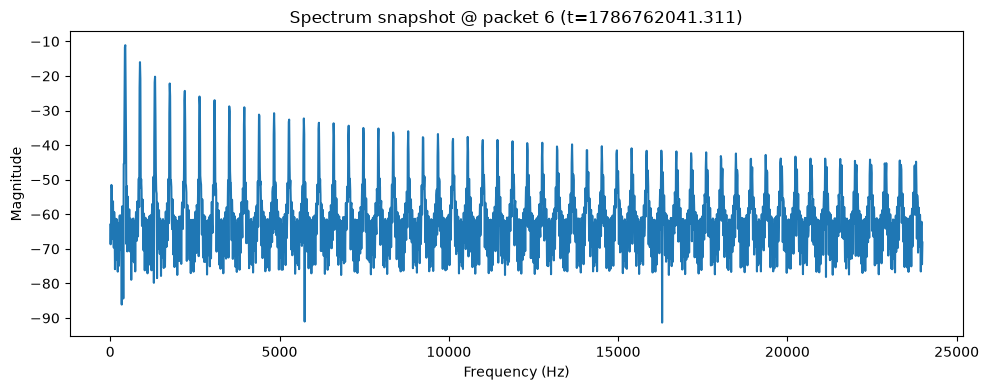

In [11]:
import matplotlib.pyplot as plt

def plot_spectrum_snapshot(timestamps, bins, packet_index=0):
    magnitude = bins[packet_index]
    freqs = bin_freqs(len(magnitude), FFT_SIZE, SAMPLE_RATE)
 
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, magnitude)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(f"Spectrum snapshot @ packet {packet_index} (t={timestamps[packet_index]:.3f})")
    plt.tight_layout()
    plt.show()

plot_spectrum_snapshot(timestamps, bins, 6)

What we can do in debug though is also plot across timestamps, which would be a spectrogram.A stable signal will look uniform horizontally. A changing

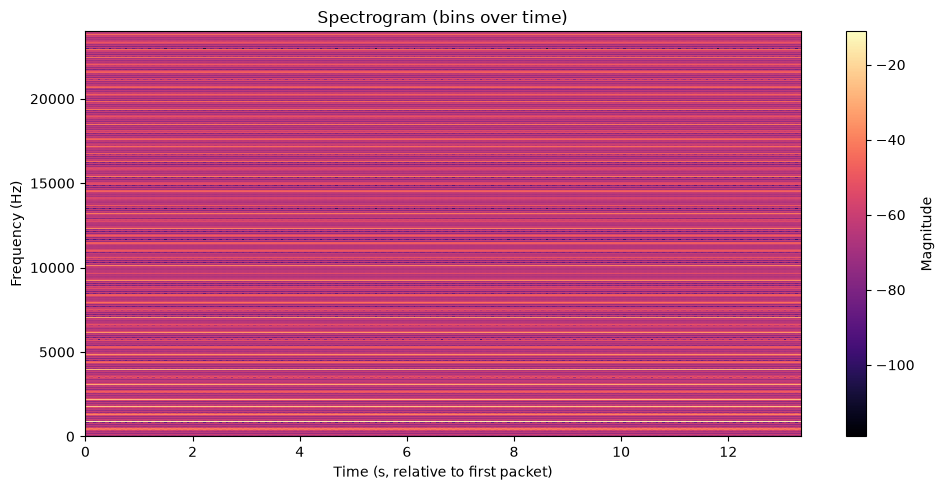

In [13]:
def plot_spectrogram(timestamps, bins):
    freqs = bin_freqs(bins.shape[1], FFT_SIZE, SAMPLE_RATE)
 
    plt.figure(figsize=(10, 5))

    plt.pcolormesh(
        timestamps - timestamps[0], freqs, bins.T,
        shading="auto", cmap="magma"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")
    plt.title("Spectrogram (bins over time)")
    plt.tight_layout()
    plt.show()

plot_spectrogram(timestamps, bins)